In [73]:
%%writefile board2048_ext.c

#define PY_SSIZE_T_CLEAN
#include <Python.h>
#include <stdint.h>
#include <string.h>
#include <time.h>

#define BOARD_SIZE 16

/**
 * BoardStruct
 * 
 * Represents the internal data structure for the game board.
 */
typedef struct {
    uint16_t data[BOARD_SIZE];
} BoardStruct;

/**
 * BoardObject
 * 
 * Represents the Python object for the game board.
 */
typedef struct {
    PyObject_HEAD
    BoardStruct board;
} BoardObject;

/**
 * __new__(cls)
 * 
 * Allocates memory for a new BoardObject and initializes the internal board data to zero.
 */
static PyObject *
Board_new(PyTypeObject *type, PyObject *args, PyObject *kwds)
{
    BoardObject *self = (BoardObject *)type->tp_alloc(type, 0);
    if (self != NULL)
        memset(self->board.data, 0, sizeof(self->board.data));
    return (PyObject *)self;
}

/**
 * __init__(self)
 * 
 * Initializes the board to the starting state of the game, with two tiles
 * containing the value 2 (represented as 1 in the internal data).
 * 
 * The initial positions of the two tiles are randomly chosen among the 16 available cells.
 */
static int
Board_init(BoardObject *self, PyObject *args, PyObject *kwds)
{
    // Place two tiles in random positions on the board
    for (int i = 0; i < 2; i++) {
        int pos;
        do {
            pos = rand() % BOARD_SIZE;
        } while (self->board.data[pos] != 0); // Ensure we place on an empty cell
        self->board.data[pos] = 1; // Place a tile
    }
    return 0;
}

/**
 * Board_sweep(self, direction)
 * 
 * Sweeps the board in the given direction (0=up, 1=right, 2=down, 3=left).
 * Returns True if any tile moved or merged, False if the board was unchanged.
 */
static PyObject *
Board_sweep(BoardObject *self, PyObject *args)
{
    int direction;
    if (!PyArg_ParseTuple(args, "i", &direction))
        return NULL;

    if (direction < 0 || direction > 3) {
        PyErr_SetString(PyExc_ValueError, "Direction must be 0 (up), 1 (right), 2 (down), or 3 (left)");
        return NULL;
    }

    int lane_start, lane_step, cell_step;

    switch (direction) {
        case 0: lane_start = 0;  lane_step = 1; cell_step =  4; break; // up
        case 1: lane_start = 3;  lane_step = 4; cell_step = -1; break; // right
        case 2: lane_start = 12; lane_step = 1; cell_step = -4; break; // down
        case 3: lane_start = 0;  lane_step = 4; cell_step =  1; break; // left
    }

    int changed = 0;

    for (int i = 0; i < 4; i++) {
        int base = lane_start + i * lane_step;

        for (int j = 0; j < 3; j++) {
            int pos = base + j * cell_step;

            for (int k = 0; k < 3 - j; k++) {
                int check = base + (j + k + 1) * cell_step;
                if (self->board.data[check] == 0)
                    continue;

                if (self->board.data[pos] == 0) {
                    self->board.data[pos] = self->board.data[check];
                    self->board.data[check] = 0;
                    changed = 1;
                } else if (self->board.data[pos] == self->board.data[check]) {
                    self->board.data[pos]++;
                    self->board.data[check] = 0;
                    changed = 1;
                    break;
                } else {
                    break;
                }
            }
        }
    }

    return PyBool_FromLong(changed);
}

/**
 * Board_place_tile(self)
 * 
 * Places a new tile on a random empty cell. The value is 1 (90% chance) or 2 (10% chance).
 * When the board is full, it checks if any moves are still possible.
 * Returns False if the board is full and there are no possible moves.
 */
static PyObject *
Board_place_tile(BoardObject *self, PyObject *Py_UNUSED(ignored))
{
    // Collect all empty cell indices
    int empty[BOARD_SIZE];
    int empty_count = 0;

    for (int i = 0; i < BOARD_SIZE; i++) {
        if (self->board.data[i] == 0)
            empty[empty_count++] = i;
    }

    // Pick a random empty cell and place tile
    int pos = empty[rand() % empty_count];
    self->board.data[pos] = (rand() % 10 == 0) ? 2 : 1;

    // Check if board is full after placement
    int full = 1;
    for (int i = 0; i < BOARD_SIZE; i++) {
        if (self->board.data[i] == 0) {
            full = 0;
            break;
        }
    }

    if (!full)
        return PyBool_FromLong(1);  // still empty cells, game continues

    // Board is full — check if any move is still possible
    // by testing all 4 directions on a copy of the board
    for (int direction = 0; direction < 4; direction++) {
        // Copy the board
        BoardStruct copy;
        memcpy(&copy, &self->board, sizeof(BoardStruct));

        // Determine sweep parameters (same logic as Board_sweep)
        int lane_start, lane_step, cell_step;
        switch (direction) {
            case 0: lane_start = 0;  lane_step = 1; cell_step =  4; break; // up
            case 1: lane_start = 3;  lane_step = 4; cell_step = -1; break; // right
            case 2: lane_start = 12; lane_step = 1; cell_step = -4; break; // down
            case 3: lane_start = 0;  lane_step = 4; cell_step =  1; break; // left
        }

        int changed = 0;
        for (int i = 0; i < 4 && !changed; i++) {
            int base = lane_start + i * lane_step;
            for (int j = 0; j < 3 && !changed; j++) {
                int pos = base + j * cell_step;
                for (int k = 0; k < 3 - j; k++) {
                    int check = base + (j + k + 1) * cell_step;
                    if (copy.data[check] == 0)
                        continue;
                    if (copy.data[pos] == 0 || copy.data[pos] == copy.data[check]) {
                        changed = 1;  // a move or merge is possible
                        break;
                    } else {
                        break;
                    }
                }
            }
        }

        if (changed)
            return PyBool_FromLong(1);  // at least one valid move exists
    }

    return PyBool_FromLong(0);  // no moves possible, game over
}

/**
 * Board_repr(self)
 * 
 * Returns a string representation of the board.
 */
static PyObject *
Board_repr(BoardObject *self)
{
    /* Build "Board([v0, v1, ..., v15])" */
    PyObject *list = PyList_New(BOARD_SIZE);
    if (!list) return NULL;
    for (int i = 0; i < BOARD_SIZE; i++)
        PyList_SET_ITEM(list, i, PyLong_FromLong(self->board.data[i]));
    PyObject *list_repr = PyObject_Repr(list);
    Py_DECREF(list);
    if (!list_repr) return NULL;
    PyObject *result = PyUnicode_FromFormat("Board(%S)", list_repr);
    Py_DECREF(list_repr);
    return result;
}

/**
 * Board_to_list(self)
 * 
 * Returns a list representation of the board.
 */
static PyObject *
Board_to_list(BoardObject *self, PyObject *Py_UNUSED(ignored))
{
    PyObject *list = PyList_New(BOARD_SIZE);
    if (!list) return NULL;
    for (int i = 0; i < BOARD_SIZE; i++)
        PyList_SET_ITEM(list, i, PyLong_FromLong(self->board.data[i]));
    return list;
}

/**
 * Board_methods
 * 
 * Defines the methods available on the Board object.
 */
static PyMethodDef Board_methods[] = {
    {
        "sweep",
        (PyCFunction)Board_sweep,
        METH_VARARGS,
        "sweep(direction)\n\n"
        "Sweep the board in the given direction (0=up, 1=right, 2=down, 3=left).\n"
        "Returns True if any tile moved or merged, False if the board was unchanged."
    },
    {
        "place_tile",
        (PyCFunction)Board_place_tile,
        METH_NOARGS,
        "place_tile()\n\n"
        "Place a new tile on a random empty cell.\n"
        "Value is 1 (90% chance) or 2 (10% chance).\n"
        "Returns True if a tile was placed, False if the board is full."
    },
    {
        "to_list",
        (PyCFunction)Board_to_list,
        METH_NOARGS,
        "to_list()\n\n"
        "Return the contents as a Python list of ints."
    },
    {NULL, NULL, 0, NULL}   /* sentinel */
};

/**
 * BoardType
 * 
 * The Python type object for the Board class.
 */
static PyTypeObject BoardType = {
    PyVarObject_HEAD_INIT(NULL, 0)
    .tp_name      = "board2048_ext.Board",
    .tp_doc       = PyDoc_STR(
        "Board() -> new Board\n\n"
        "A 4x4 game board for the 2048 game.\n\n"
    ),
    .tp_basicsize = sizeof(BoardObject),
    .tp_itemsize  = 0,
    .tp_flags     = Py_TPFLAGS_DEFAULT | Py_TPFLAGS_BASETYPE,
    .tp_new       = Board_new,
    .tp_init      = (initproc)Board_init,
    .tp_repr      = (reprfunc)Board_repr,
    .tp_methods   = Board_methods,
};

/**
 * board2048_module
 */
static PyModuleDef board2048_module = {
    PyModuleDef_HEAD_INIT,
    .m_name = "board2048_ext",
    .m_doc = "C extension module for a 2048 game board.",
    .m_size = -1,
};

/**
 * PyInit_board2048_ext
 */
PyMODINIT_FUNC
PyInit_board2048_ext(void)
{
    srand((unsigned int)time(NULL)); // Seed the random number generator

    PyObject *m;
    if (PyType_Ready(&BoardType) < 0)
        return NULL;

    m = PyModule_Create(&board2048_module);
    if (m == NULL)
        return NULL;

    Py_INCREF(&BoardType);
    if (PyModule_AddObject(m, "Board", (PyObject *)&BoardType) < 0) {
        Py_DECREF(&BoardType);
        Py_DECREF(m);
        return NULL;
    }

    return m;
}

Overwriting board2048_ext.c


In [74]:
%%writefile setup.py
"""
setup.py – build the board2048_ext C extension.

Usage:
    python setup.py build_ext --inplace
"""

from setuptools import setup, Extension

module = Extension(
    "board2048_ext",
    sources=["board2048_ext.c"],
    extra_compile_args=["-std=c11"],
)

setup(
    name="board2048_ext",
    version="1.0",
    description="Python C extension: board2048",
    ext_modules=[module],
)


Overwriting setup.py


In [75]:
!python setup.py build_ext --inplace

running build_ext
building 'board2048_ext' extension
x86_64-linux-gnu-gcc -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/include/python3.12 -c board2048_ext.c -o build/temp.linux-x86_64-cpython-312/board2048_ext.o -std=c11
x86_64-linux-gnu-gcc -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -g -fwrapv -O2 build/temp.linux-x86_64-cpython-312/board2048_ext.o -L/usr/lib/x86_64-linux-gnu -o build/lib.linux-x86_64-cpython-312/board2048_ext.cpython-312-x86_64-linux-gnu.so
copying build/lib.linux-x86_64-cpython-312/board2048_ext.cpython-312-x86_64-linux-gnu.so -> 


In [ ]:
import math

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from board2048_ext import Board

class Env2048(gym.Env):
    """Gymanisum environment for the 2048 game."""
    
    def __init__(self):
        super().__init__()
        
        # 4 actions : 0 (Up), 1 (Right), 2 (Down), 3 (Left)
        self.action_space = spaces.Discrete(4)
        
        # Observations space 
        self.observation_space = spaces.Box(
            low=0, 
            high=16, 
            shape=(4, 4), 
            dtype=np.int32
        )
        
        self.board = None

        self.consecutive_invalid_moves = 0

    def get_score(self, board):
        return sum((2**v if v > 0 else 0) for v in board.to_list())

    def _get_obs(self):
        """Takes the current board state and converts it into a 4x4 NumPy array of integers."""
        board_list = self.board.to_list()
        return np.array(board_list, dtype=np.int32).reshape((4, 4))

    # Create a new board at the start of each episode
    def reset(self, seed=None, options=None):
        """Resets the game at the beginning of an episode."""
        super().reset(seed=seed) # Required by Gymnasium
        
        self.board = Board()
        
        obs = self._get_obs()
        info = {}
        
        return obs, info

    # Step function: apply action, calculate reward, check for termination
    def step(self, action):
        action = int(action)
        score_before = self.get_score(self.board)
        moved = self.board.sweep(action)
        
        terminated = False
        truncated = False
        
        # If the move was invalid (no tiles moved or merged), give a penalty and check for termination
        if not moved:

            self.consecutive_invalid_moves += 1
            reward = -10.0
            
            # If the agent makes more than 2 invalid moves in a row, end the episode to prevent infinite loops
            if self.consecutive_invalid_moves > 2:
                terminated = True 

            return self._get_obs(), reward, terminated, truncated, {}

        self.consecutive_invalid_moves = 0
            
        game_continues = self.board.place_tile()
        score_after = self.get_score(self.board)
        

        diff = score_after - score_before
        if diff > 0:
            reward = math.log2(diff) # We take the logarithm of the score difference to give a more balanced reward
        else:
            reward = -0.1 # Small penalty for moves that don't increase the score, to encourage the agent to find better moves
            
        if not game_continues:
            terminated = True
            
        return self._get_obs(), reward, terminated, truncated, {}
        

    def render(self):
        """Displays the board in the console."""
        if self.board is None:
            return
            
        obs = self._get_obs()
        print("-" * 25)
        for row in obs:
            row_vals = [2**val if val > 0 else 0 for val in row]
            print(f"| {row_vals[0]:^4} | {row_vals[1]:^4} | {row_vals[2]:^4} | {row_vals[3]:^4} |")
        print("-" * 25)

In [77]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

env = Env2048()
obs, info = env.reset()
env.render()

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)


# To ensure reproducibility during training, you can fix the random seeds
# by uncommenting the lines below. This makes the results consistent across
# runs, which is helpful for debugging or comparing different approaches.
#
# That said, allowing randomness can be beneficial in practice, as it lets
# the model explore different training trajectories.


# seed = 42
# random.seed(seed)
# torch.manual_seed(seed)
# env.reset(seed=seed)
# env.action_space.seed(seed)
# env.observation_space.seed(seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(seed)

-------------------------
|  0   |  0   |  2   |  0   |
|  0   |  0   |  0   |  0   |
|  0   |  0   |  0   |  0   |
|  0   |  0   |  2   |  0   |
-------------------------


In [78]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [ ]:
class DQN(nn.Module):
    def __init__(self, n_actions=4):
        super(DQN, self).__init__()
        # 16 channels input for one-hot encoding of tile values (0-15)
        self.conv1 = nn.Conv2d(16, 128, kernel_size=2)
        self.conv2 = nn.Conv2d(128, 256, kernel_size=2)
        
        # After two conv layers with kernel size 2, the spatial dimensions go from 4x4 to 3x3 to 2x2
        # 256 filters * 2 * 2 = 1024
        self.fc1 = nn.Linear(1024, 512)
        self.head = nn.Linear(512, n_actions)

    # How the input flows through the network to produce the output Q-values for each action
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.head(x)

In [80]:
# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the ``AdamW`` optimizer

BATCH_SIZE = 256
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 50000
TAU = 0.005
LR = 1e-4


# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = 16

policy_net = DQN(n_actions=n_actions).to(device)
target_net = DQN(n_actions=n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(100000)


steps_done = 0


def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [ ]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

# In 2048, the state is represented as a 4x4 grid of integers, where each integer represents the exponent of 2 for the tile value (0 for empty, 1 for 2, 2 for 4, ..., up to 15 for 32768). 
# To feed this into a neural network, we can convert it into a one-hot encoded tensor with 16 channels (one for each possible tile value from 0 to 15). 
# This way, the network can learn separate features for each tile value.
def process_state(obs_np, device):
    """Convert the 4x4 NumPy board directly into a One-Hot Tensor on the GPU."""
    t = torch.tensor(obs_np, dtype=torch.long, device=device).clamp(max=15)
    t_oh = F.one_hot(t, num_classes=16).permute(2, 0, 1).unsqueeze(0).float()
    return t_oh

Training Episodes:   3%|▎         | 5610/200000 [30:00<17:19:55,  3.12it/s]



 Time Limit reached (30.0 min).
Complete


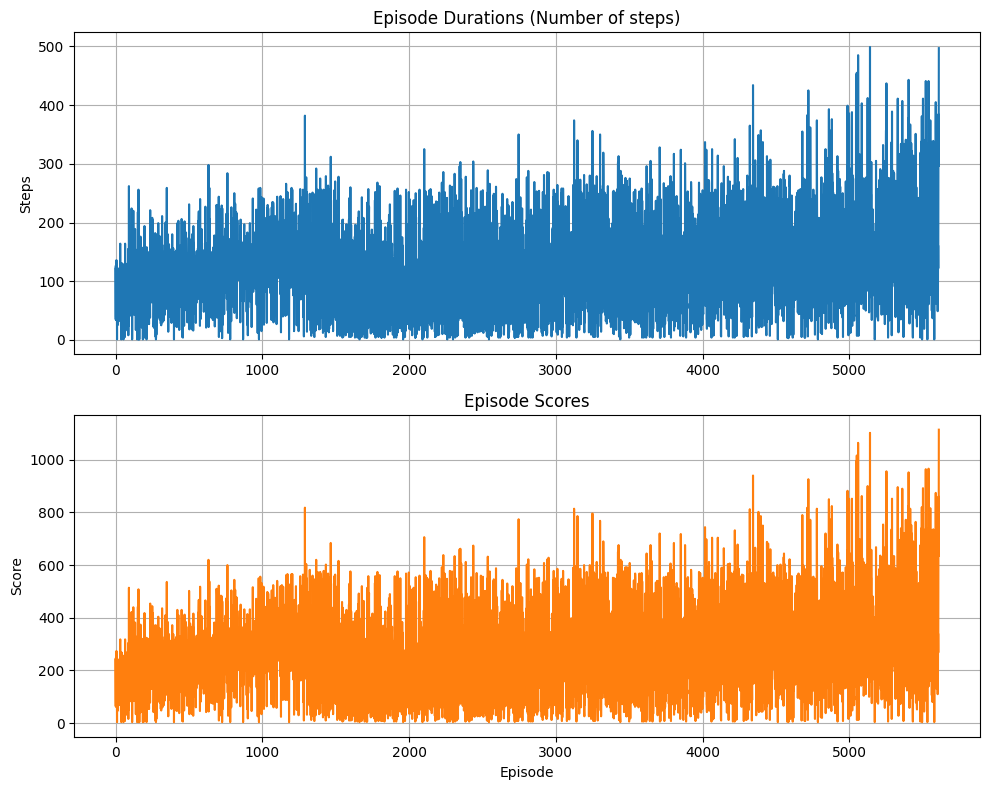

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import count
import torch
import time


MAX_TRAINING_TIME_SECONDS = 1800
start_time = time.time()


if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 200000
else:
    num_episodes = 50

# Lists to keep track of progress
episode_durations = []
episode_final_scores = []
best_score = 0

# Wrap the range with tqdm for a progress bar
for i_episode in tqdm(range(num_episodes), desc="Training Episodes"):

    elapsed_time = time.time() - start_time
    if elapsed_time > MAX_TRAINING_TIME_SECONDS:
        print(f"\n Time Limit reached ({elapsed_time/60:.1f} min).")
        break # End training loop if time limit is exceeded
    
    # Initialize the environment and get its state
    state, info = env.reset()
    state = process_state(state, device)
    

    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
                
        reward_tensor = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = process_state(observation, device)

        # Store the transition in memory
        memory.push(state, action, next_state, reward_tensor)

        # Move to the next state
        state = next_state

        # Optimize the model every 4 steps to balance training speed and stability       
        if steps_done % 4 == 0:
            optimize_model()
            
            # Soft update of the target network's weights
            # θ′ ← τ θ + (1 −τ )θ′
            target_net_state_dict = target_net.state_dict()
            policy_net_state_dict = policy_net.state_dict()
            for key in policy_net_state_dict:
                target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
            target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            
            board_score = env.unwrapped.get_score(env.unwrapped.board)
            episode_final_scores.append(board_score)
            
            # Save the best model based on the highest score achieved so far
            if board_score > best_score:
                best_score = board_score
                torch.save(policy_net.state_dict(), "dqn_2048_BEST.pth")
                
            break
            

print('Complete')

# ---------------------------------------------------------
# Final Plotting: Durations and Scores
# ---------------------------------------------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Episode Durations (Number of steps)
axs[0].plot(episode_durations, color='tab:blue')
axs[0].set_title('Episode Durations (Number of steps)')
axs[0].set_ylabel('Steps')
axs[0].grid(True)

# Plot 2: Episode Scores
axs[1].plot(episode_final_scores, color='tab:orange')
axs[1].set_title('Episode Scores')
axs[1].set_xlabel('Episode')
axs[1].set_ylabel('Score')
axs[1].grid(True)

plt.tight_layout()
plt.show()